In [1]:
import argparse
import os
import pickle
import time
import warnings

import torch
import torchrl.data.tensor_specs
from torch.distributions.uniform import Uniform
torchrl.data.tensor_specs.CompositeSpec = torchrl.data.tensor_specs.Composite
torchrl.data.tensor_specs.BoundedTensorSpec = torchrl.data.tensor_specs.Bounded
torchrl.data.tensor_specs.UnboundedDiscreteTensorSpec = torchrl.data.tensor_specs.UnboundedDiscrete
torchrl.data.tensor_specs.UnboundedContinuousTensorSpec = torchrl.data.tensor_specs.UnboundedContinuous
from rl4co.data.transforms import StateAugmentation
from rl4co.utils.ops import gather_by_index, unbatchify
from tqdm.auto import tqdm
from routefinder.data.utils import get_dataloader
from routefinder.envs import MTVRPEnv
from routefinder.models import RouteFinderBase, RouteFinderMoE
from routefinder.models.baselines.mtpomo import MTPOMO
from routefinder.models.baselines.mvmoe import MVMoE

# Tricks for faster inference
try:
    torch._C._jit_set_profiling_executor(False)
    torch._C._jit_set_profiling_mode(False)
except AttributeError:
    pass

torch.set_float32_matmul_precision("medium")

/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class VRPArgument():
    def __init__(self):
        self.checkpoint = 'checkpoints/100/rf-transformer.ckpt'
        self.problem = 'all' #cvrp, vrptw, etc. or all
        self.size = 100
        self.datasets = None
        self.batch_size = 1000
        self.device = 'cpu'
        self.remove_mixed_backhaul = True
warnings.filterwarnings("ignore", message=".*weights_only.*", category=FutureWarning)
opts = VRPArgument()
device = torch.device("cpu")

In [3]:
def test(
    policy,
    td,
    env,
    num_augment=8,
    augment_fn="dihedral8",  # or symmetric. Default is dihedral8 for reported eval
    num_starts=None,
    device="cuda",
):

    costs_bks = td.get("costs_bks", None)

    with torch.inference_mode():
        with (
            torch.amp.autocast("cuda")
            if "cuda" in str(device)
            else torch.inference_mode()
        ):  # Use mixed precision if supported
            n_start = env.get_num_starts(td) if num_starts is None else num_starts

            if num_augment > 1:
                td = StateAugmentation(num_augment=num_augment, augment_fn=augment_fn)(td)

            # Evaluate policy
            out = policy(td, env, phase="test", num_starts=n_start, return_actions=True)

            # Unbatchify reward to [batch_size, num_augment, num_starts].
            reward = unbatchify(out["reward"], (num_augment, n_start))

            if n_start > 1:
                # max multi-start reward
                max_reward, max_idxs = reward.max(dim=-1)
                out.update({"max_reward": max_reward})

                if out.get("actions", None) is not None:
                    # Reshape batch to [batch_size, num_augment, num_starts, ...]
                    actions = unbatchify(out["actions"], (num_augment, n_start))
                    out.update(
                        {
                            "best_multistart_actions": gather_by_index(
                                actions, max_idxs, dim=max_idxs.dim()
                            )
                        }
                    )
                    out["actions"] = actions

            # Get augmentation score only during inference
            if num_augment > 1:
                # If multistart is enabled, we use the best multistart rewards
                reward_ = max_reward if n_start > 1 else reward
                max_aug_reward, max_idxs = reward_.max(dim=1)
                out.update({"max_aug_reward": max_aug_reward})

                # If costs_bks is available, we calculate the gap to BKS
                if costs_bks is not None:
                    # note: torch.abs is here as a temporary fix, since we forgot to
                    # convert rewards to costs. Does not affect the results.
                    gap_to_bks = (
                        100
                        * (-max_aug_reward - torch.abs(costs_bks))
                        / torch.abs(costs_bks)
                    )
                    out.update({"gap_to_bks": gap_to_bks})

                if out.get("actions", None) is not None:
                    actions_ = (
                        out["best_multistart_actions"] if n_start > 1 else out["actions"]
                    )
                    out.update({"best_aug_actions": gather_by_index(actions_, max_idxs)})

            if out.get("gap_to_bks", None) is None:
                out.update({"gap_to_bks": 69420})  # Dummy value

            return out

In [4]:
def extract_routes_from_actions(actions, drop_empty_routes=True):
    """
    Parse giant-tour actions into per-route lists. Robust to both conventions:
    - depot markers placed before each route (0, a, b, 0, c, d, 0, ...)
    - depot markers placed after each route (a, b, 0, c, d, 0, ...)
    Args:
        actions: 1D or 2D Tensor/list. If 2D, shape [batch, seq_len].
        drop_empty_routes: if True, omit routes that contain no customers (i.e., [0]).
    Returns:
        If input was 1D: list[list[int]] of routes (each starts with 0 followed by clients).
        If input was 2D: list of batches -> list[list[list[int]]].
    """
    single = False
    if isinstance(actions, torch.Tensor):
        actions = actions.cpu()
    if not isinstance(actions, (list, tuple)) and not hasattr(actions, "__iter__"):
        raise TypeError("actions must be a tensor or an iterable")
    # Normalize to list-of-lists
    if isinstance(actions, torch.Tensor) and actions.dim() == 1:
        actions = actions.unsqueeze(0)
        single = True
    elif isinstance(actions, torch.Tensor) and actions.dim() == 2:
        pass
    elif isinstance(actions, (list, tuple)) and (len(actions) and not isinstance(actions[0], (list, tuple))):
        # single sequence provided as list -> wrap
        actions = [list(actions)]
        single = True
    elif isinstance(actions, (list, tuple)):
        # assume list of sequences
        pass
    else:
        raise TypeError("Unsupported actions format")
    routes_batch = []
    for seq in actions:
        # get plain python list of ints
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
        seq = [int(x) for x in seq]
        # Split on zeros: segments are sequences between zeros.
        segments = []
        curr = []
        for val in seq:
            if val == 0:
                # zero acts as separator/end-of-route marker
                segments.append(curr)
                curr = []
            else:
                curr.append(val)
        # Add trailing segment (if sequence did not end with 0)
        if curr or not segments:
            segments.append(curr)
        # Convert segments -> routes that start with depot 0
        routes = []
        for seg in segments:
            if len(seg) == 0:
                route = [0]  # empty route (no customers)
            else:
                route = [0] + seg
            if drop_empty_routes and route == [0]:
                continue
            routes.append(route)
        routes_batch.append(routes)
    routes = routes_batch[0] if single else routes_batch
    for i in routes:
        for r in i:
            r.append(0)
    return routes

In [5]:
if opts.datasets is not None:
    data_paths = opts.datasets.split(",")
else:
    # list recursively all npz files in data/
    data_paths = []
    for root, _, files in os.walk("data"):
        for file in files:
            # print(file)
            if "test" not in root:
                continue
            if file.endswith(".npz"):
                if opts.remove_mixed_backhaul and "m" in root:
                    continue
                # if name in 50 or 100, append
                if str(opts.size) in file:
                    if file == "50.npz" or file == "100.npz":
                        data_paths.append(os.path.join(root, file))
    assert len(data_paths) > 0, "No datasets found. Check the data directory."
    data_paths = sorted(sorted(data_paths), key=lambda x: len(x))
    print(f"Found {len(data_paths)} datasets on the following paths: {data_paths}")

Found 16 datasets on the following paths: ['data/cvrp/test/100.npz', 'data/ovrp/test/100.npz', 'data/vrpb/test/100.npz', 'data/vrpl/test/100.npz', 'data/ovrpb/test/100.npz', 'data/ovrpl/test/100.npz', 'data/vrpbl/test/100.npz', 'data/vrptw/test/100.npz', 'data/ovrpbl/test/100.npz', 'data/ovrptw/test/100.npz', 'data/vrpbtw/test/100.npz', 'data/vrpltw/test/100.npz', 'data/ovrpbtw/test/100.npz', 'data/ovrpltw/test/100.npz', 'data/vrpbltw/test/100.npz', 'data/ovrpbltw/test/100.npz']


In [6]:
# Load model
print("Loading checkpoint from ", opts.checkpoint)
if "mvmoe" in opts.checkpoint:
    BaseLitModule = MVMoE
elif "mtpomo" in opts.checkpoint:
    BaseLitModule = MTPOMO
elif "moe" in opts.checkpoint:
    BaseLitModule = RouteFinderMoE
else:
    BaseLitModule = RouteFinderBase

model = BaseLitModule.load_from_checkpoint(
    opts.checkpoint, map_location="cpu", strict=False
)
# checkpoint = torch.load(opts.checkpoint, map_location="cpu", weights_only=False)
# model = BaseLitModule.load_from_checkpoint(checkpoint, strict=False)
env = MTVRPEnv()
policy = model.policy.to(device).eval()  # Use mixed precision if supported

Loading checkpoint from  checkpoints/100/rf-transformer.ckpt


/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/n.tu/3T/test/routefinder/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.


In [7]:
dataset = 'data/vrptw/test/100.npz'

In [8]:
print(f"Loading {dataset}")
td_test = env.load_data(dataset)
td_test = td_test[:5]

Loading data/vrptw/test/100.npz


In [9]:
td_test

TensorDict(
    fields={
        actions_bks: Tensor(shape=torch.Size([5, 121]), device=cpu, dtype=torch.int64, is_shared=False),
        costs_bks: Tensor(shape=torch.Size([5]), device=cpu, dtype=torch.float32, is_shared=False),
        demand_linehaul: Tensor(shape=torch.Size([5, 100]), device=cpu, dtype=torch.float32, is_shared=False),
        locs: Tensor(shape=torch.Size([5, 101, 2]), device=cpu, dtype=torch.float32, is_shared=False),
        num_depots: Tensor(shape=torch.Size([5, 1]), device=cpu, dtype=torch.int32, is_shared=False),
        service_time: Tensor(shape=torch.Size([5, 101]), device=cpu, dtype=torch.float32, is_shared=False),
        speed: Tensor(shape=torch.Size([5, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        time_windows: Tensor(shape=torch.Size([5, 101, 2]), device=cpu, dtype=torch.float32, is_shared=False),
        vehicle_capacity: Tensor(shape=torch.Size([5, 1]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size

In [10]:
print(td_test[0]['actions_bks'])
print("="*100)
print(td_test[0]['costs_bks'])
print("="*100)
print(td_test[0]['demand_linehaul'])
print("="*100)
print(td_test[0]['locs'])
print("="*100)
print(td_test[0]['num_depots'])
print("="*100)
print(td_test[0]['speed'])
print("="*100)
print(td_test[0]['vehicle_capacity'])
print("="*100)

tensor([ 39,  11,  97,  72,   0,  64,  34,  76,  20,  67,   0,  38,  47,  58,
         55,  32,  62,   0,  74,  36,  92,  26,   8,   0,  85,  42,  95,  73,
         98,  31,   0,  16,  68,  52,  66,  57,   0,  40,  17,  71,  15,  51,
          2,  44,  22,   0,  90,  79,  35,  61,  91,  29,  84,  50,   0,  48,
          9,  12,  59,  75,  82,  41,   0,  89,   4,  81, 100,  77,   6,  83,
         94,  24,   0,  86,  46,  78,  27,  60,  28,  99,  43,   0,   3,  33,
         19,  56,  88,  93,   1,  13,   0,  70,  18,  54,  37,   0,  63,  10,
          7,   5,   0,  96,  87,  80,   0,  25,  53,  23,  21,  49,   0,  45,
          0,  65,  14,  69,  30,   0,   0,   0,   0])
tensor(-23.4560)
tensor([0.0600, 0.1600, 0.1400, 0.0800, 0.1400, 0.0800, 0.0600, 0.1400, 0.0400,
        0.1000, 0.0600, 0.0800, 0.0200, 0.0400, 0.1200, 0.1200, 0.1800, 0.1400,
        0.1200, 0.0400, 0.1400, 0.0800, 0.0600, 0.1200, 0.1000, 0.1800, 0.0200,
        0.1400, 0.1400, 0.0600, 0.1000, 0.0400, 0.1800, 0.0800, 0

In [11]:
print(td_test[0]['service_time'])
print("="*100)
print(td_test[0]['time_windows'])
print("="*100)

tensor([0.0000, 0.1524, 0.1600, 0.1679, 0.1696, 0.1525, 0.1724, 0.1532, 0.1632,
        0.1722, 0.1551, 0.1527, 0.1720, 0.1532, 0.1757, 0.1744, 0.1760, 0.1590,
        0.1667, 0.1588, 0.1635, 0.1602, 0.1648, 0.1754, 0.1610, 0.1798, 0.1746,
        0.1634, 0.1658, 0.1609, 0.1684, 0.1744, 0.1591, 0.1543, 0.1578, 0.1619,
        0.1663, 0.1562, 0.1539, 0.1528, 0.1734, 0.1564, 0.1678, 0.1525, 0.1565,
        0.1710, 0.1602, 0.1754, 0.1711, 0.1743, 0.1618, 0.1610, 0.1608, 0.1719,
        0.1650, 0.1509, 0.1692, 0.1636, 0.1661, 0.1687, 0.1557, 0.1512, 0.1710,
        0.1604, 0.1752, 0.1630, 0.1710, 0.1776, 0.1551, 0.1672, 0.1567, 0.1634,
        0.1560, 0.1701, 0.1666, 0.1519, 0.1528, 0.1660, 0.1565, 0.1602, 0.1795,
        0.1727, 0.1620, 0.1608, 0.1795, 0.1701, 0.1587, 0.1721, 0.1728, 0.1740,
        0.1798, 0.1512, 0.1658, 0.1762, 0.1519, 0.1641, 0.1741, 0.1769, 0.1613,
        0.1747, 0.1652])
tensor([[0.0000, 4.6000],
        [3.3908, 3.5719],
        [3.1126, 3.3111],
        [0.4126, 

In [12]:
dataloader = get_dataloader(td_test, batch_size=opts.batch_size)

In [13]:
start = time.time()
res = []
for batch in dataloader:
    td_test = env.reset(batch).to(device)
    o = test(policy, td_test, env, device=device)
    actions = o["best_aug_actions"]  # shape: [batch_size, seq_len]
    routes = extract_routes_from_actions(actions)
    res.append(o)
out = {}
out["max_aug_reward"] = torch.cat([o["max_aug_reward"] for o in res])
out["gap_to_bks"] = torch.cat([o["gap_to_bks"] for o in res])
    
inference_time = time.time() - start

dataset_name = dataset.split("/")[-3].split(".")[0].upper()
print(
    f"{dataset_name} | Cost: {-out['max_aug_reward'].mean().item():.3f} | Gap: {out['gap_to_bks'].mean().item():.3f}% | Inference time: {inference_time:.3f} s"
)

VRPTW | Cost: 27.503 | Gap: 3.191% | Inference time: 0.780 s


In [14]:
print(len(routes))
print(len(routes[0]))

5
18


In [15]:
routes[0]

[[0, 64, 34, 76, 92, 26, 8, 0],
 [0, 16, 68, 52, 66, 57, 0],
 [0, 89, 4, 81, 100, 29, 82, 41, 0],
 [0, 85, 42, 95, 73, 98, 31, 24, 0],
 [0, 48, 9, 78, 77, 84, 28, 99, 43, 0],
 [0, 38, 90, 71, 15, 75, 2, 44, 22, 0],
 [0, 17, 12, 91, 59, 50, 0],
 [0, 74, 36, 58, 55, 32, 62, 0],
 [0, 40, 79, 35, 61, 51, 6, 1, 13, 0],
 [0, 33, 19, 46, 27, 60, 37, 0],
 [0, 70, 18, 54, 96, 87, 80, 0],
 [0, 3, 86, 56, 88, 93, 30, 0],
 [0, 39, 20, 67, 0],
 [0, 47, 83, 94, 0],
 [0, 25, 11, 97, 72, 0],
 [0, 63, 10, 7, 69, 5, 0],
 [0, 65, 14, 45, 0],
 [0, 53, 23, 21, 49, 0]]

In [16]:
actions[0]

tensor([ 64,  34,  76,  92,  26,   8,   0,  16,  68,  52,  66,  57,   0,  89,
          4,  81, 100,  29,  82,  41,   0,  85,  42,  95,  73,  98,  31,  24,
          0,  48,   9,  78,  77,  84,  28,  99,  43,   0,  38,  90,  71,  15,
         75,   2,  44,  22,   0,  17,  12,  91,  59,  50,   0,  74,  36,  58,
         55,  32,  62,   0,  40,  79,  35,  61,  51,   6,   1,  13,   0,  33,
         19,  46,  27,  60,  37,   0,  70,  18,  54,  96,  87,  80,   0,   3,
         86,  56,  88,  93,  30,   0,  39,  20,  67,   0,  47,  83,  94,   0,
         25,  11,  97,  72,   0,  63,  10,   7,  69,   5,   0,  65,  14,  45,
          0,  53,  23,  21,  49,   0,   0,   0,   0])

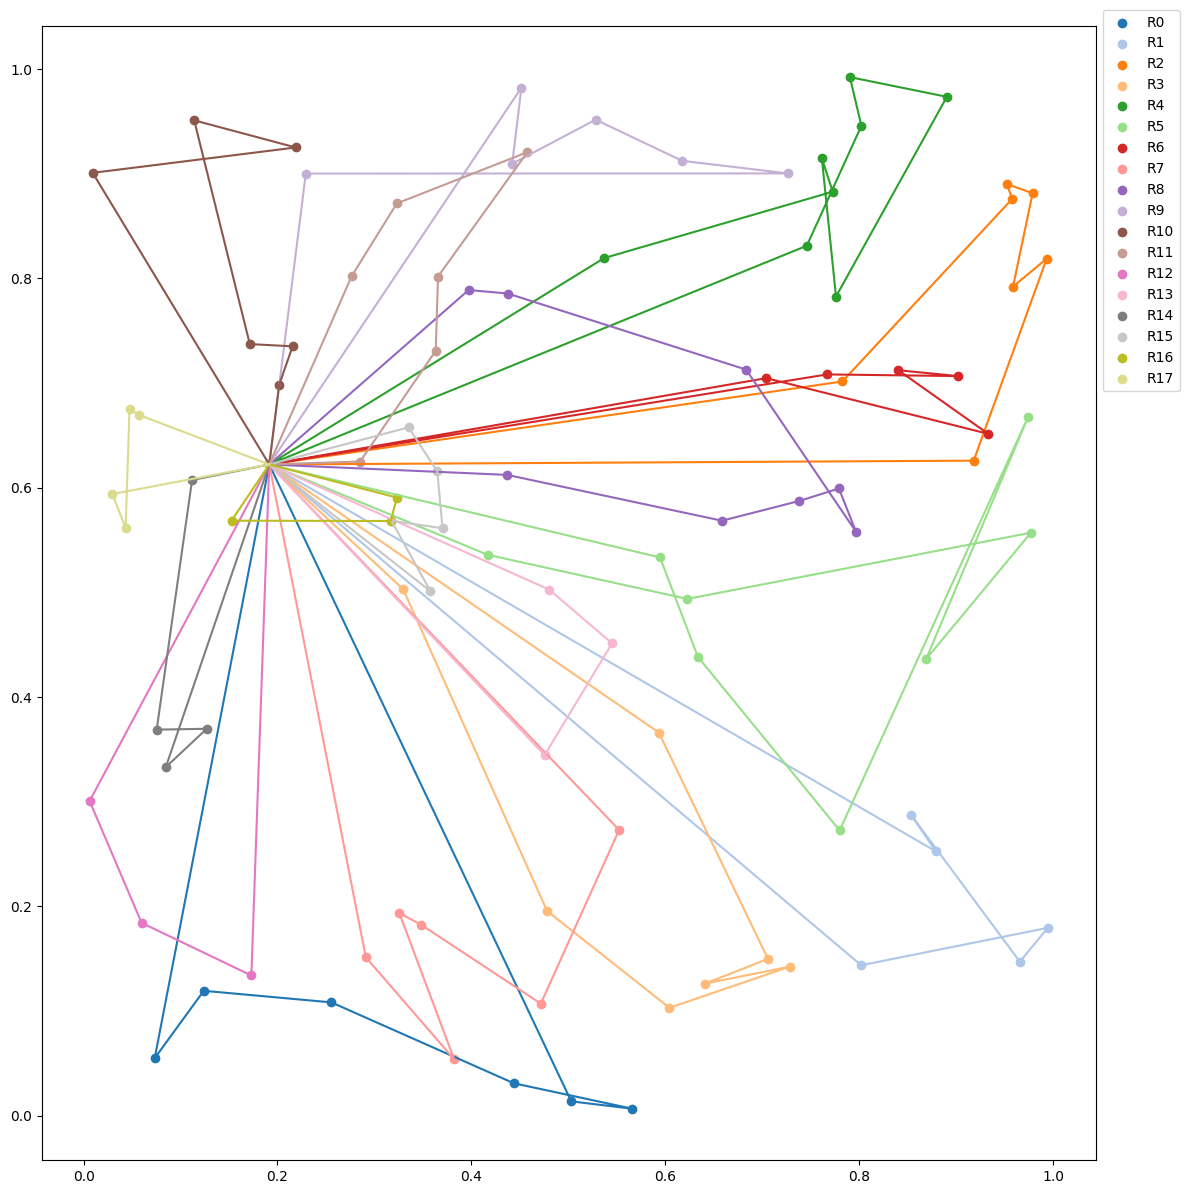

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import cycle

def route_visualize(coordinates, routes):
    coordinates = pd.DataFrame(coordinates, columns=["x", "y"])
    num_location = coordinates.shape[0]
    #
    cmap = mpl.colormaps["tab20"]
    colors = cycle(cmap.colors)
    # Now the figure
    figsize = [max(int(num_location / 8), 5), max(int(num_location / 8), 5)]
    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    for r, tour in enumerate(routes):
        c = next(colors)
        t = np.array(tour)
        x = coordinates.values[t, 0]
        y = coordinates.values[t, 1]
        ax.scatter(x, y, color=c, label=f"R{r}")
        ax.plot(x, y, color=c)

    ax.legend(loc="upper left", bbox_to_anchor=(1, 1.02))
    fig.tight_layout()
    plt.show()
    return
route_visualize(td_test[0]['locs'].tolist(), routes[0])

In [18]:
from pyvrp import Model, Client, Depot
from pyvrp.stop import MaxRuntime
from scipy.spatial.distance import pdist, squareform
from itertools import cycle

def vrptw_model(num_vehicles, capacity, coordinates, demands, distances):
    m = Model()
    m.add_vehicle_type(
        num_available=num_vehicles,
        capacity=[capacity],
        # tw_early=time_windows[0][0],
        # tw_late=time_windows[0][1],
    )
    depot = m.add_depot(
        x=coordinates[0][0],
        y=coordinates[0][1],
        # tw_early=time_windows[0][0],
        # tw_late=time_windows[0][1],
    )
    clients = [
        m.add_client(
            x=coordinates[idx][0],
            y=coordinates[idx][1],
            delivery=[demands[idx]],
            # tw_early=time_windows[idx][0],
            # tw_late=time_windows[idx][1],
            # service_duration=service_time[idx],
        )
        for idx in range(1, len(coordinates))
    ]
    #
    for frm_idx, frm in enumerate(m.locations):
        for to_idx, to in enumerate(m.locations):
            distance = distances[frm_idx][to_idx]
            m.add_edge(frm, to, distance=distance)
    #
    time_limit = int(len(demands)) * 240 / 100
    print("Time limit: ", time_limit)
    res = m.solve(stop=MaxRuntime(time_limit), display=False)
    print("Feasible solution: ", res.is_feasible())
    print(res)
    return res, m

In [19]:
distances = squareform(pdist(td_test[0]['locs'].tolist(), metric="euclidean"))
distances = np.round(distances*1000000, decimals=6)
distances

array([[     0.      , 295413.334588, 684428.556922, ..., 663160.105673,
        691201.733564, 829054.741856],
       [295413.334588,      0.      , 616492.274242, ..., 702302.205537,
        398282.994376, 549735.798813],
       [684428.556922, 616492.274242,      0.      , ..., 244082.549766,
        673333.281402, 640365.764128],
       ...,
       [663160.105673, 702302.205537, 244082.549766, ...,      0.      ,
        865413.137052, 863647.27675 ],
       [691201.733564, 398282.994376, 673333.281402, ..., 865413.137052,
             0.      , 188009.540653],
       [829054.741856, 549735.798813, 640365.764128, ..., 863647.27675 ,
        188009.540653,      0.      ]], shape=(101, 101))

In [20]:
res, model = vrptw_model(50,
                         int(td_test[0]['vehicle_capacity'].item()*100),
                         td_test[0]['locs'].tolist(),
                         (td_test[0]['demand_linehaul']*100).int().tolist(),
                         distances,
                        )

Time limit:  242.4
Feasible solution:  True
Solution results
    # routes: 10
     # trips: 10
   # clients: 100
   objective: 14559901
    distance: 14559901
    duration: 0
# iterations: 363595
    run-time: 242.40 seconds

Routes
------
Route #1: 94 74 95 98 26 8 92 32 36 31
Route #2: 1 27 28 99 84 81 4 100 82 29 50
Route #3: 87 3 86 33 46 56 19 88 93 63
Route #4: 20 64 34 67 76 62 58 55
Route #5: 10 40 22 90 44 85 83 47 38 7
Route #6: 30 65 69 14 5 24 97 72 39 11 45
Route #7: 80 96 37 18 54 70 21 49 53 23 25
Route #8: 13 48 60 78 9 43 77 17 6
Route #9: 2 66 57 68 52 16 73 42
Route #10: 89 91 59 75 12 41 71 15 51 61 35 79



In [21]:
def save_solution(res, demands, model, save_path):
    sol = res.best
    routes = []
    for i, route in enumerate(sol.routes()):
        routes.append(
            {
                "route_id": i,
                "vehicle_type": route.vehicle_type(),
                "visits": route.visits(),
                "delivery": route.delivery()[0],
                "distance": route.distance(),
                "vehicle_utilization": sum(demands[cust] for cust in route.visits())
                / model.vehicle_types[route.vehicle_type()].capacity[0],
            }
        )
    df = pd.DataFrame(routes)
    df.to_csv(save_path, index=False)
    return
save_solution(res, (td_test[0]['demand_linehaul']*100).int().tolist(), model, 'output/results.csv')

In [22]:
routes = []
for i in res.best.routes():
    route = i.visits()
    route.insert(0, 0)
    route.append(0)
    routes.append(route)

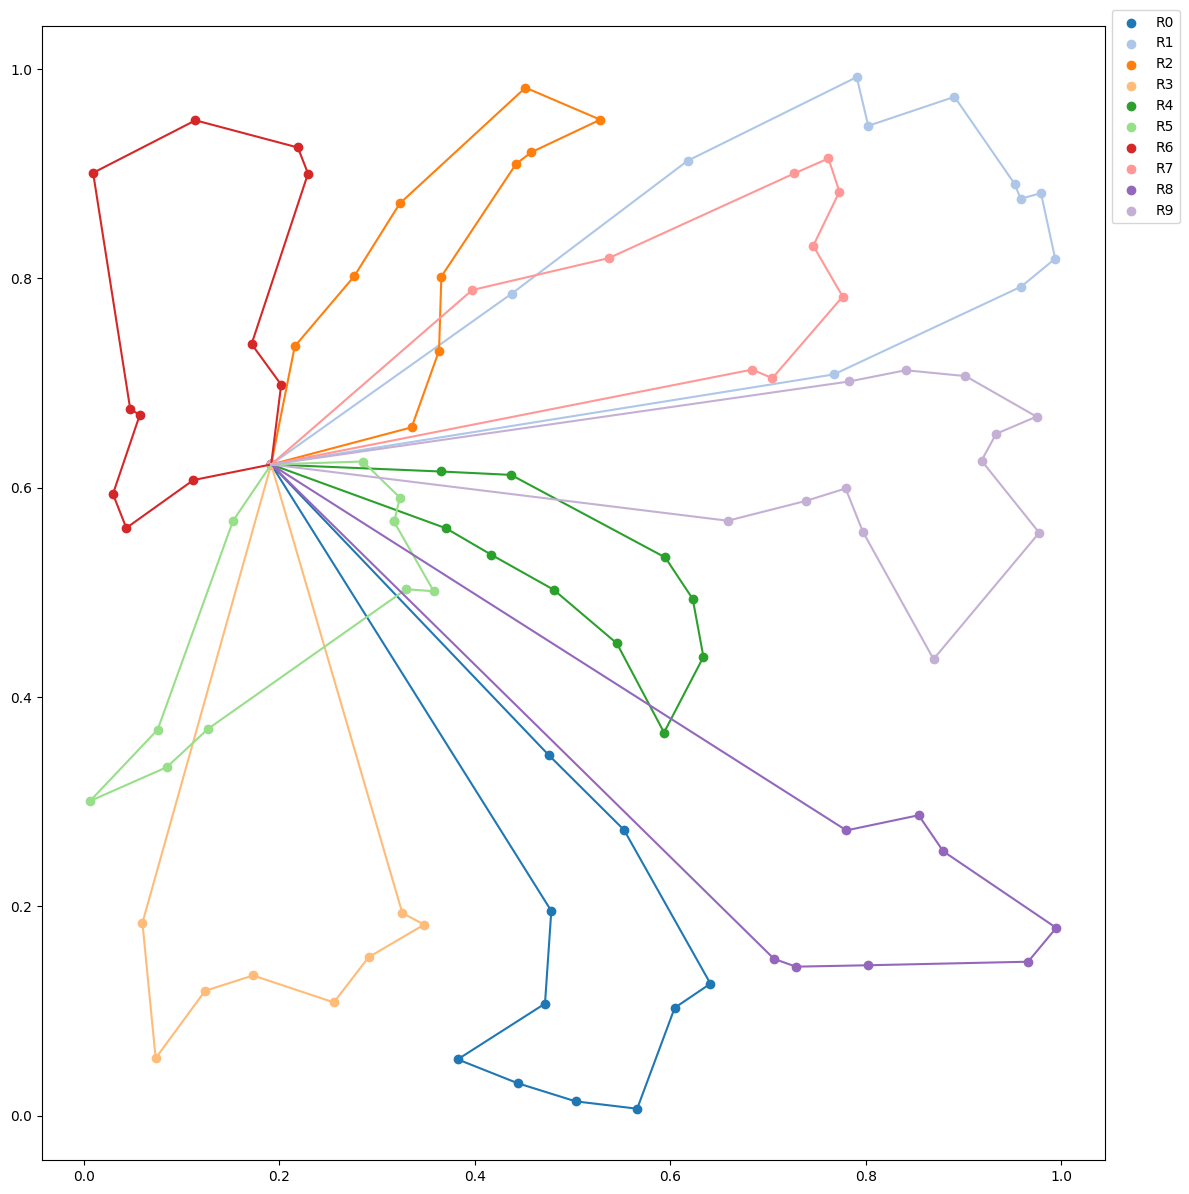

In [23]:
route_visualize(td_test[0]['locs'].tolist(), routes)

In [24]:
# print(td_test[0]['demand_linehaul'])
# print(td_test[0]['locs'])
# print(td_test[0]['num_depots'])
# print(td_test[0]['speed'])
# print(td_test[0]['vehicle_capacity'])
# print(td_test[0]['service_time'])
# print(td_test[0]['time_windows'])